In [ ]:
from pathlib import Path
from typing import List, Sequence, Optional, Any, Tuple
from plotnine import (
	ggplot,
	aes,
	geom_path, geom_point,
	xlab, ylab,
	theme, element_text, element_rect, element_line,
  	scale_y_continuous
   )
from plotnine.themes import theme_classic
import plotnine.scales as scales
import polars as pl
import pandas as pd

In [2]:
# --- Load Excel file ---
def load_file(file_name: str, sheet_name= None) -> pl.DataFrame:
    
    """Load an Excel file as a DataFrame with a fast engine for processing Excel files.
    Parameters:
    - file_name
    - sheet_name: Excel sheet required or None to load the first sheet
    Returns a pandas DataFrame"""
    
    # 1. Get the folder where THIS script lives
    script_location = Path.cwd()
    
    # 2. Build the path to the file relative to the script
    file_path = script_location / "Data" / file_name
    
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f'File not found: {file_path}')
    # Let pandas choose a working engine (openpyxl, xlrd, etc.). If your environment requires a specific engine, pass it here.
    df = pl.read_excel(path, sheet_name=sheet_name, engine="calamine")
    df.columns = [
    c.strip()
    .replace(" (", "(")   # <--- Removes space before (
    .replace(" ", "_")    # <--- Turns remaining spaces to underscores
    for c in df.columns
    ]
    return df

In [3]:
# Example:
df = load_file("LFP/LFP_2nd_Test/Moha_LFP_gradC_14mg_Channel_1_Wb_1.xlsx", "Channel-1_1")
df.head()

Could not determine dtype for column 13, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 15, falling back to string


Data_Point,Date_Time,Test_Time(s),Step_Time(s),Cycle_Index,Step_Index,Current(A),Voltage(V),Power(W),Charge_Capacity(Ah),Discharge_Capacity(Ah),Charge_Energy(Wh),Discharge_Energy(Wh),ACR(Ohm),dV/dt(V/s),Internal_Resistance(Ohm),dQ/dV(Ah/V),dV/dQ(V/Ah)
i64,datetime[ms],f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64
1,2025-11-20 18:00:37.891,60.0009,60.0009,1,1,0.0,1.6679,0.0,0.0,0.0,0.0,0.0,null,0.33792,null,null,null
2,2025-11-20 18:01:37.891,120.0005,120.0005,1,1,0.0,1.6794,0.0,0.0,0.0,0.0,0.0,null,0.12987,null,null,null
3,2025-11-20 18:02:37.891,180.0006,180.0006,1,1,0.0,1.6817,0.0,0.0,0.0,0.0,0.0,null,-0.16572,null,0.0,0.0
4,2025-11-20 18:03:37.891,240.0005,240.0005,1,1,0.0,1.6855,0.0,0.0,0.0,0.0,0.0,null,0.052731,null,null,null
5,2025-11-20 18:04:37.891,300.0006,300.0006,1,1,0.0,1.6679,0.0,0.0,0.0,0.0,0.0,null,0.090514,null,0.0,0.0


In [4]:
def edit_excel(active_m: float, df: pl.DataFrame, export_excel: bool, path: str = None) -> pl.DataFrame:
    
    # Add computed columns in one call (casts for safety)
    df = df.drop("Internal_Resistance(Ohm)", "ACR(Ohm)")
    df = df.with_columns([
        (pl.col("Step_Time(s)").cast(pl.Float64) / 3600).alias("Time(h)"),
        (abs((pl.col("Step_Time(s)").cast(pl.Float64) / 3600) * pl.col("Current(A)").cast(pl.Float64) * 1000 / active_m))
            .alias("Specific_Capacity(mAh/g)"),
        (pl.col("dQ/dV(Ah/V)").cast(pl.Float64) * 1000 / active_m).alias("Specific_dQ/dV")
        ])

    if export_excel:
        # Save: prefer pandas fallback for broad compatibility
        df.to_pandas().to_excel(path if path is not None else "Edited_Excel.xlsx", index=False)
    
    return df
#df = load_file("LFP/LFP_2nd_Test/moha_LFP_grad5C_14mg_Channel_6_Wb_1.xlsx", "Channel-6_1")
#df = edit_excel(0.0031, df, export_excel=False)


In [5]:
#df.head()

In [6]:
# --- Filtering function ---
def filtering(df: pl.DataFrame, filter_column_names: Sequence[str], ranges: Sequence[Sequence[Any]]) -> pl.DataFrame:
    """Filter `df` by multiple columns using membership tests (isin).
    - `filter_column_names`: sequence of column names to filter on
    - `ranges`: sequence of sequences containing allowed values for each corresponding column
    Returns the filtered DataFrame."""
    if len(filter_column_names) != len(ranges):
        raise ValueError('filter_column_names and ranges must have the same length')
    
    # Use lazy execution for better performance on chains of filters
    lf = df.lazy()
    
    for col, criteria in zip(filter_column_names, ranges):
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found in DataFrame")
        
        # LOGIC CHANGE: Check type of 'criteria'
        if isinstance(criteria, tuple) and len(criteria) == 2:
            # If it's a tuple (min, max), use is_between
            # accurate for "around 2.5" logic
            lower_bound, upper_bound = criteria
            lf = lf.filter(pl.col(col).is_between(lower_bound, upper_bound))
        else:
            # If it's a list/sequence, use standard is_in
            lf = lf.filter(pl.col(col).is_in(criteria))
        
    return lf.collect()

In [7]:
#Plotting Specific_dQ/dV vs Voltage(V)
def spec_dQdV_df(df: pl.DataFrame, range: Sequence[Sequence[int]]) -> pl.DataFrame:
    """Prepare DataFrame for plotting Specific_dQ/dV vs Voltage(V).
    Filters for Cycle_Index 1 and Step_Index 2 or 3, adjusts Specific_dQ/dV sign for discharge steps.
    Returns the modified DataFrame."""
    
    discharge_steps = range[1][1::2]  # Define discharge steps
    
    df_sp_dQdV = filtering(df, ["Cycle_Index", "Step_Index"], range)

    df_sp_dQdV = df_sp_dQdV.filter(pl.col("Specific_dQ/dV").is_not_null() &
                                (pl.col("Specific_dQ/dV").is_not_nan()) &
                                (pl.col("Specific_dQ/dV") != 0)
                                )
    
    df_sp_dQdV = df_sp_dQdV.with_columns(
                            pl.when((pl.col("Step_Index").is_in(discharge_steps)))
                            .then(pl.col("Specific_dQ/dV") * -1)
                            .otherwise(pl.col("Specific_dQ/dV"))
                            .alias("Specific_dQ/dV")  # Ensures it overwrites the original column
                            )
    
    df_sp_dQdV = df_sp_dQdV.filter(pl.col("dQ/dV(Ah/V)").is_not_null() &
                                (pl.col("dQ/dV(Ah/V)").is_not_nan()) &
                                (pl.col("dQ/dV(Ah/V)") != 0)
                                )
    
    df_sp_dQdV = df_sp_dQdV.with_columns(
                            pl.when((pl.col("Step_Index").is_in(discharge_steps)))
                            .then(pl.col("dQ/dV(Ah/V)") * -1)
                            .otherwise(pl.col("dQ/dV(Ah/V)"))
                            .alias("dQ/dV(Ah/V)")  # Ensures it overwrites the original column
                            )
    return df_sp_dQdV

In [30]:
def plotnine_ploting(
    df: pl.DataFrame,
    multiple_graphs: bool = True,
    show_legend: bool = True,
    points_and_lines: int = 0,
    column_filter: Optional[str] = '',
    column_x: str = 'Cycle_Index',
    column_y: str = 'Specific Capacity (mAh/g)',
    x_label: str = '',
    y_label: str = '',
    y_continuous: bool = False,
    plot_title: str = 'Plot',
    folder_name: str = 'default',
    markevery: int = 1,
    save_base: str = 'Cycling/plots',
    overwrite: bool = False,
    dpi: int = 400,
    width: float = 8,
    height: float = 6,
    units: str = 'in')-> Tuple[str, str]:
    
    # Convert to pandas for plotnine
    df = pd.DataFrame(df.to_pandas())

    # Build ggplot using aes_string for dynamic column names
    # Base ggplot mapping
    aes_mapping = dict(x=column_x, y=column_y)
    
    # Determine if grouping should be applied
    use_grouping = column_filter in df.columns if column_filter else False
    
    # Prepare grouping column if present
    if use_grouping:
        df[column_filter] = df[column_filter].astype('category')
        
    if multiple_graphs and use_grouping:
        aes_mapping.update(color=column_filter, group=column_filter)
    gg = ggplot(df, aes(**aes_mapping))

    # Sample points for markers
    if markevery > 1:
        if multiple_graphs and use_grouping:
            point_df = (df.assign(_idx=df.groupby(column_filter, observed=True).cumcount()).loc[lambda d: d["_idx"] % markevery == 0].drop(columns="_idx"))
        else:
            point_df = df.iloc[::markevery].copy()
    else:
        point_df = df.copy()

    # Define layers
    layers = []
    if points_and_lines in [0, 2]:
        layers.append(geom_path(size=0.8))  # Slightly thicker line for publications
    if points_and_lines in [1, 2]:
        layers.append(geom_point(data=point_df, size=4, stroke=0.5))  # Larger points for visibility
    for layer in layers:
        gg = gg + layer

    # Colormap for multiple graphs
    if multiple_graphs and use_grouping:
        gg = gg + scales.scale_colour_discrete()
        
    # Add scales safely
    if y_continuous:
        gg += scale_y_continuous(limits=(0, None))

    gg = (gg + xlab(x_label)
          + ylab(y_label)
          + theme_classic(base_size=12)
          + theme(                  
                axis_text=element_text(size=12),
                axis_title=element_text(size=12),
                plot_title=element_text(size=12, weight='bold'),
                legend_position='right' if show_legend else 'none',
                panel_background=element_rect(fill='white'),
                panel_border=element_rect(color='black', size=2),
                figure_size=(width, height),
                panel_grid_major=element_line(color="gray", size=0.7),
                panel_grid_minor=element_line(color="gray", size=0.25),
         )
        )

    if not show_legend:
        gg = gg + theme(legend_position='none')
    
    gg.show()
    # Prepare save paths
    save_folder = Path(save_base) / folder_name
    save_folder.mkdir(parents=True, exist_ok=True)
    safe_title = plot_title.replace(' ', '_').replace('/', '_')
    save_paths = {
        'PNG': save_folder / f"{safe_title}.png",
        'PDF': save_folder / f"{safe_title}.pdf"
    }

    # Save files
    for fmt, path in save_paths.items():
        if path.exists() and not overwrite:
            print(f"Skipping existing {fmt} (overwrite=False): {path}")
        else:
            gg.save(str(path), dpi=dpi if fmt == 'PNG' else None, width=width, height=height, units=units)
            print(f"{fmt} saved to {path}")

    return str(save_paths['PNG']), str(save_paths['PDF'])

In [9]:
def build_selected_cycles(df: pl.DataFrame, start: Tuple[int, int], mid: int, end: Tuple[int, int]) -> List[int]:
    cycles = sorted(df['Cycle_Index'].unique())
    return sorted(set(cycles[start[0]:start[1]] + [c for c in cycles if c % mid == 0] + cycles[end[0]:end[1]]))

Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 17, falling back to string


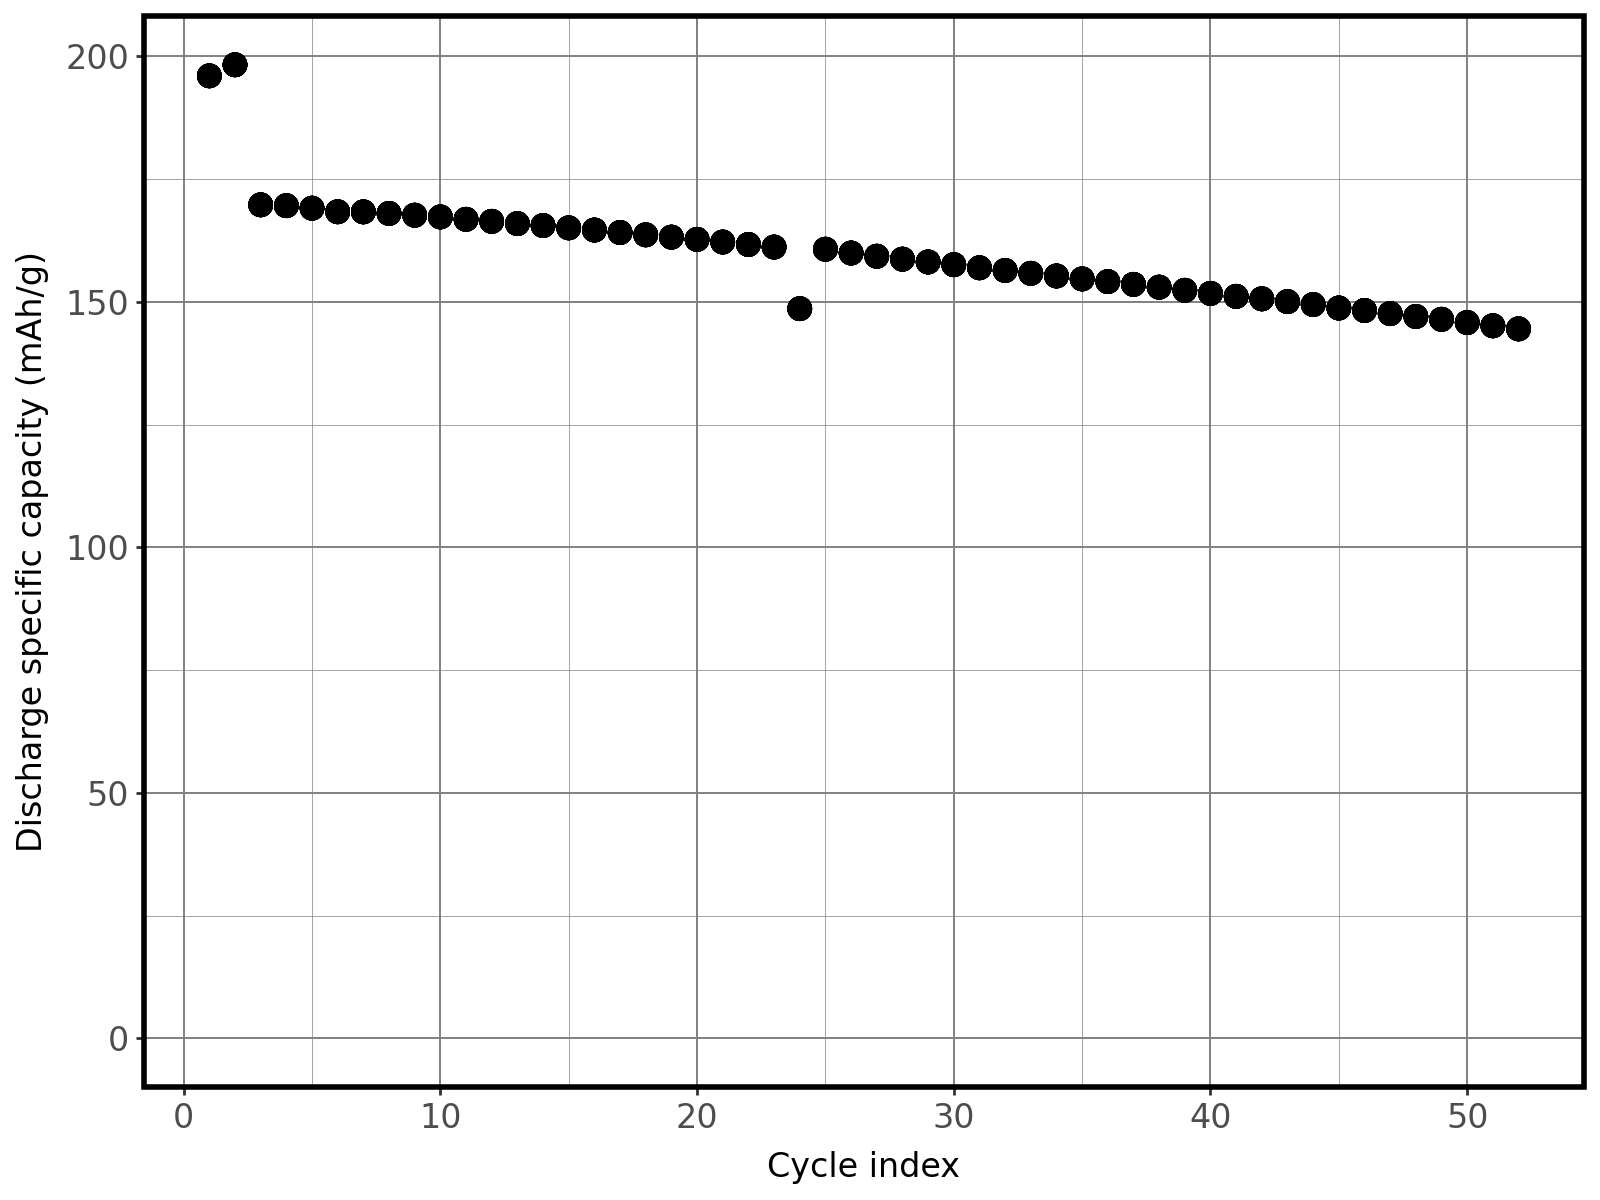

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Discharge_Retention.png


PNG saved to Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Discharge_Retention.png
PDF saved to Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Discharge_Retention.pdf


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Discharge_Retention.pdf


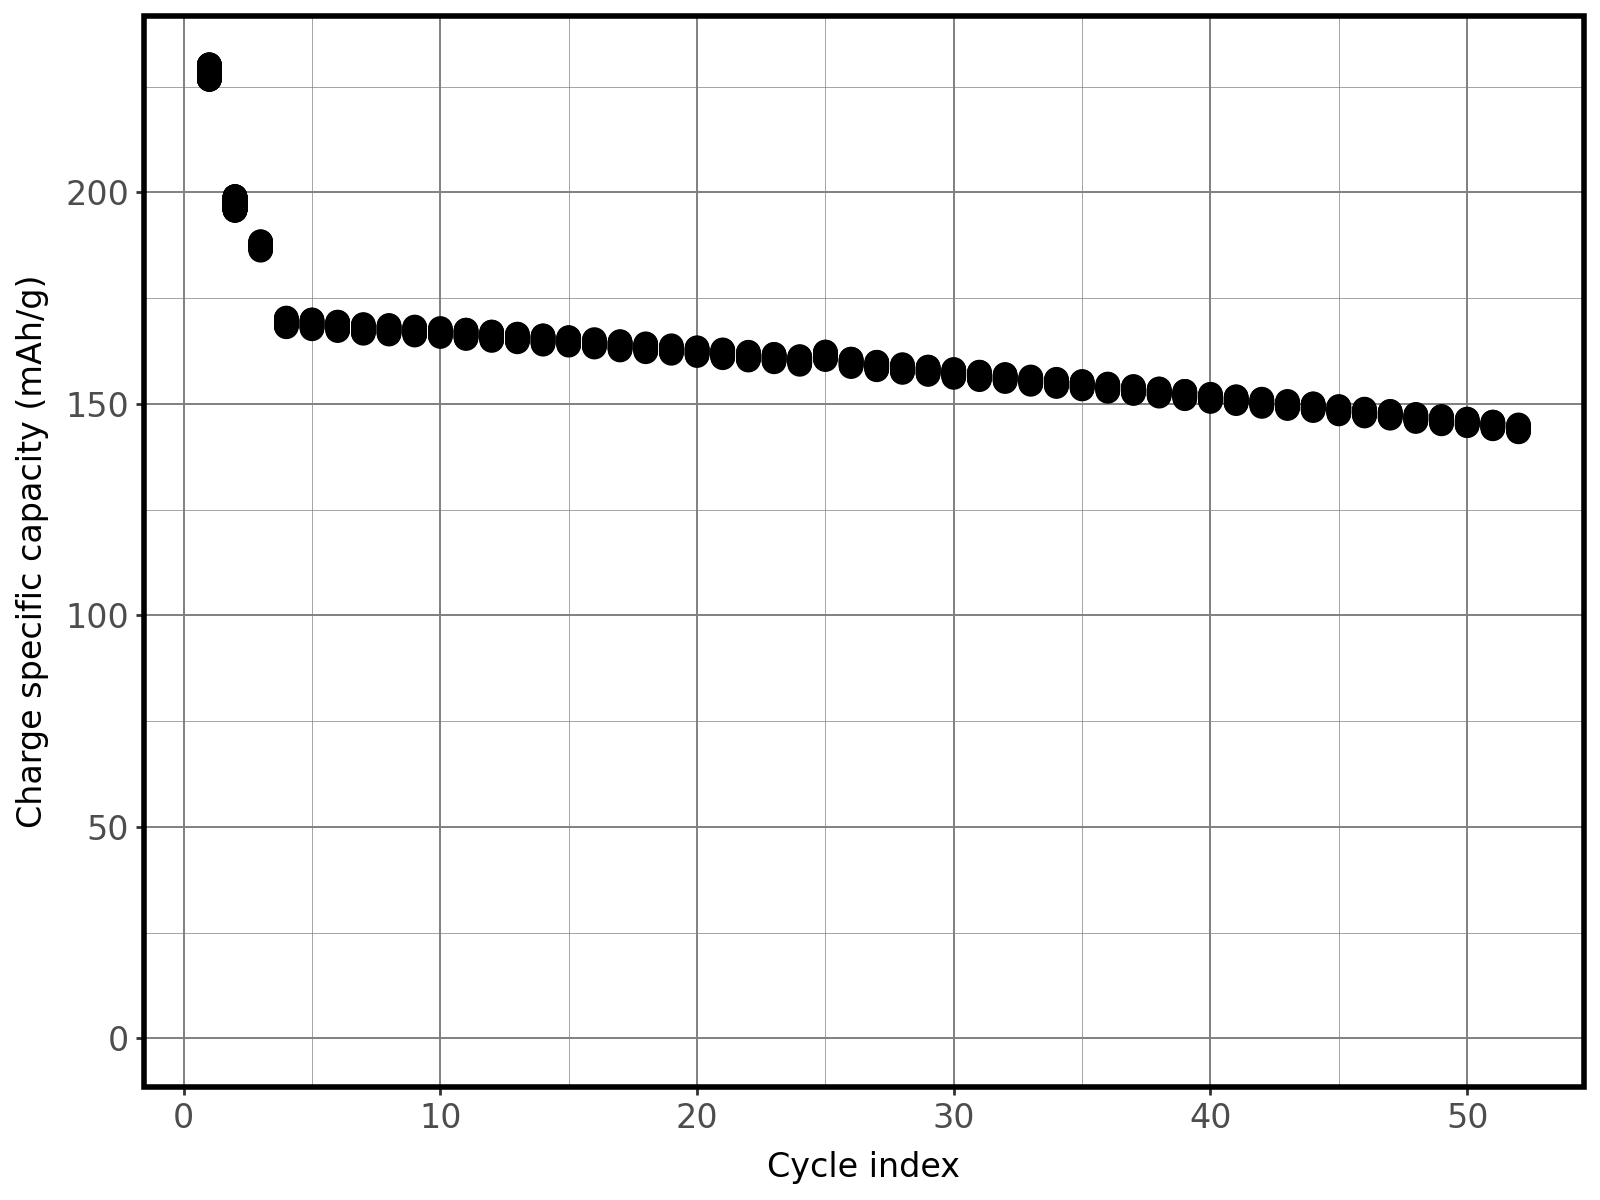

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Charge_Retention.png


PNG saved to Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Charge_Retention.png
PDF saved to Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Charge_Retention.pdf


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Charge_Retention.pdf


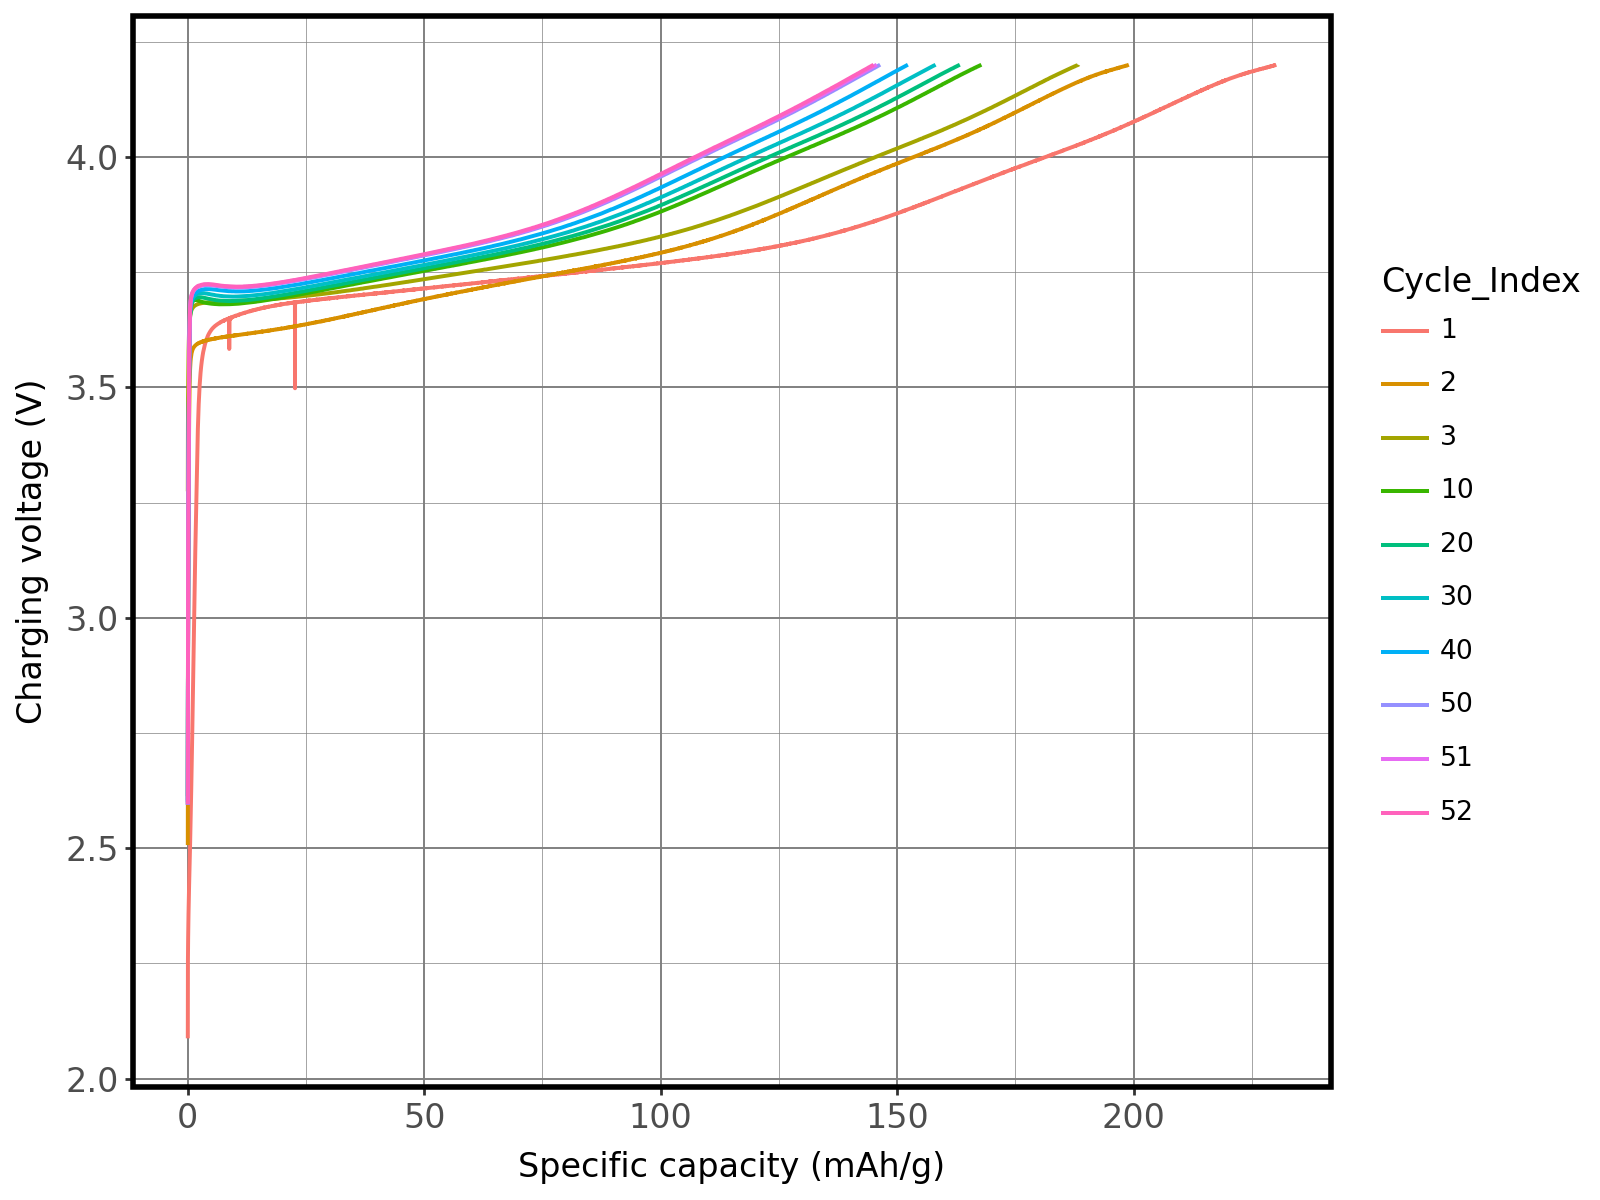

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Charging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).png


PNG saved to Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Charging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).png


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Charging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).pdf


PDF saved to Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Charging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).pdf


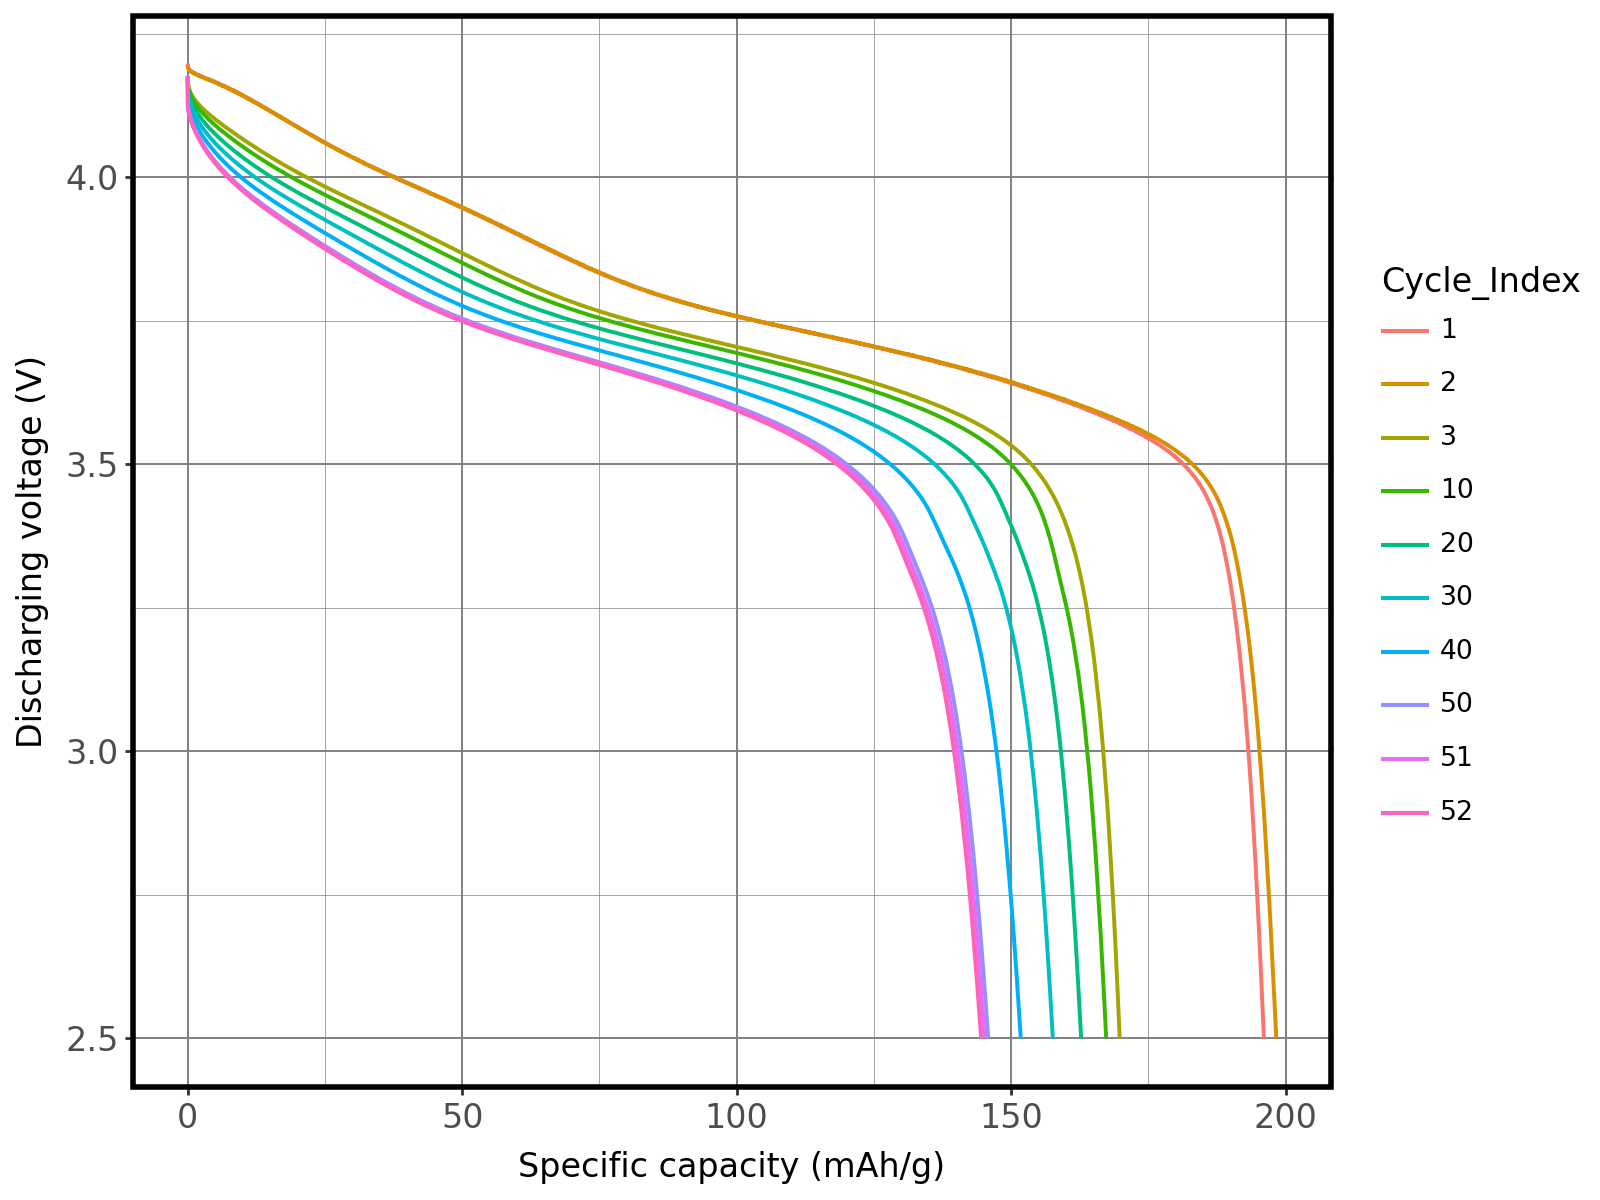

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).png


PNG saved to Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).png


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).pdf


PDF saved to Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Discharging_Voltage_(V)_vs_Specific_Capacity_(mAh_g).pdf


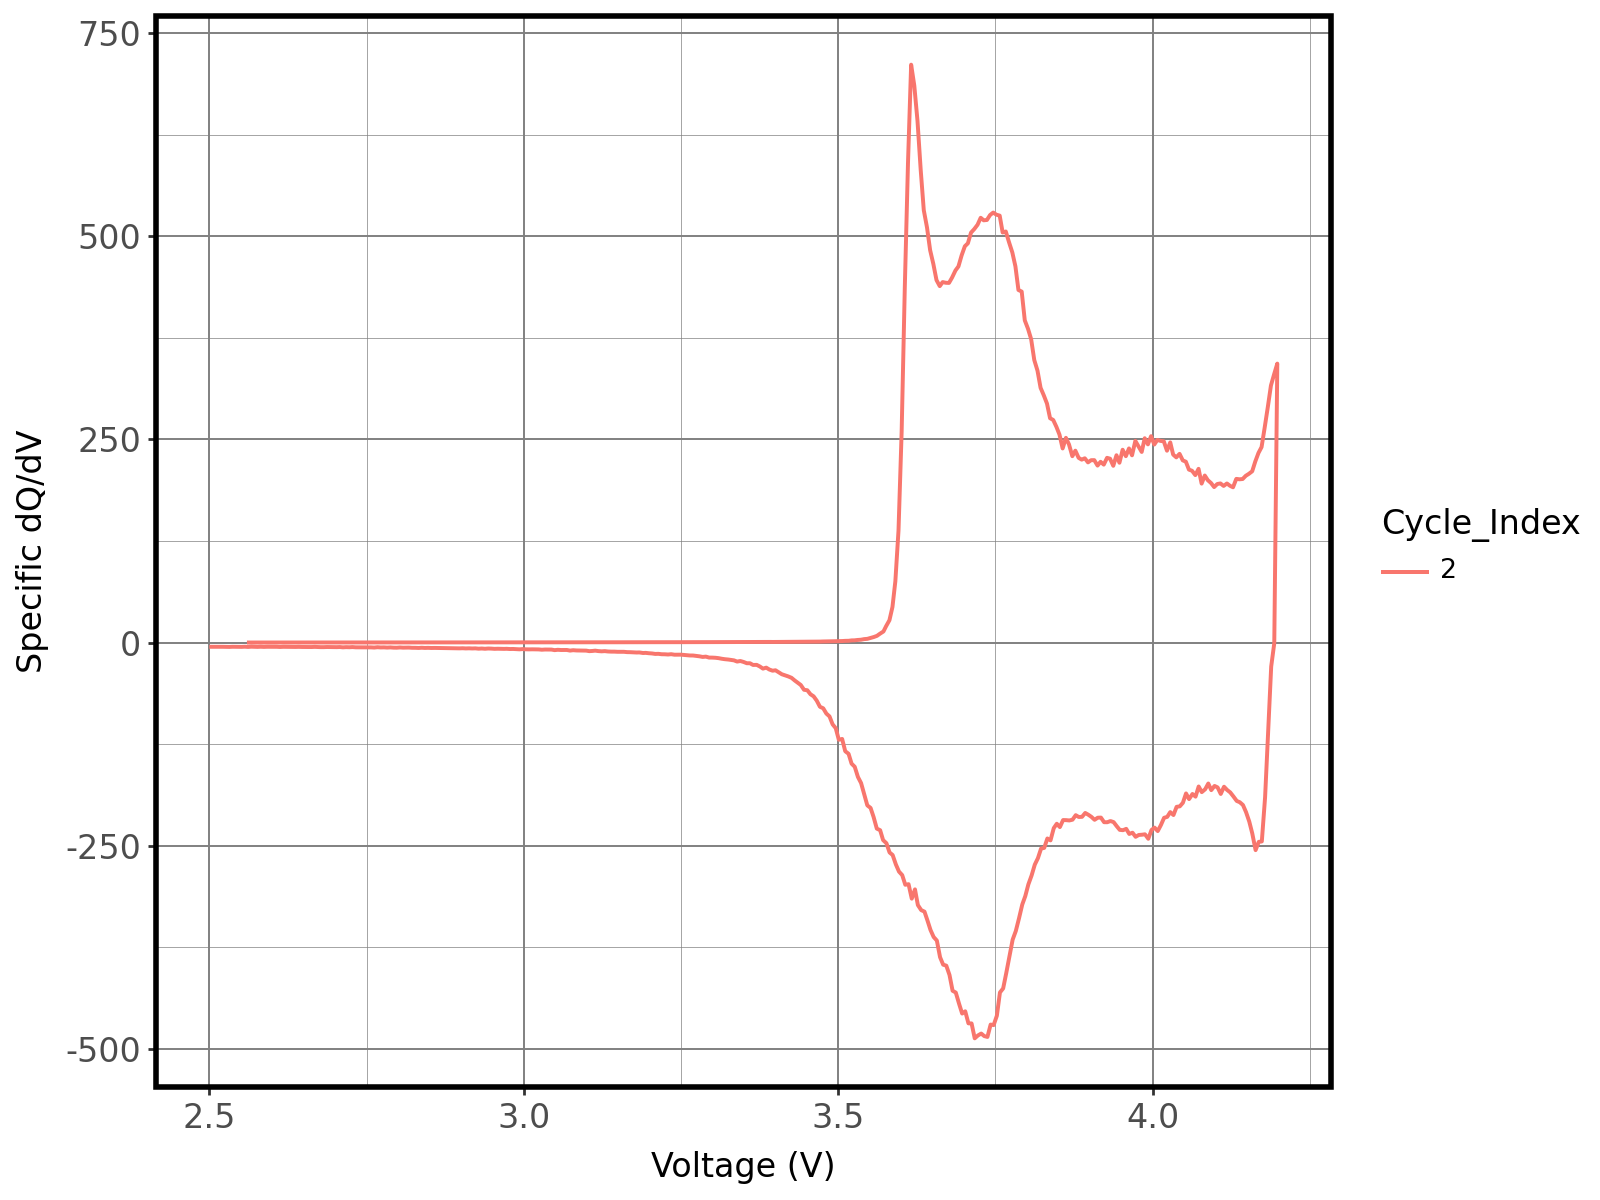

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Voltage_(V)_vs_Specific_dQ_dV.png


PNG saved to Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Voltage_(V)_vs_Specific_dQ_dV.png
PDF saved to Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Voltage_(V)_vs_Specific_dQ_dV.pdf


c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: Cycling\plots\Moha_NMC_250_112_Channel_9_Wb_1\Voltage_(V)_vs_Specific_dQ_dV.pdf


('Cycling\\plots\\Moha_NMC_250_112_Channel_9_Wb_1\\Voltage_(V)_vs_Specific_dQ_dV.png',
 'Cycling\\plots\\Moha_NMC_250_112_Channel_9_Wb_1\\Voltage_(V)_vs_Specific_dQ_dV.pdf')

In [31]:
file_path = "NMC/Moha_NMC_250_112_Channel_9_Wb_1.xlsx"
folder_name = Path(file_path).stem
df = load_file(file_path, "Channel-9_1")
df = edit_excel(0.006224, df, export_excel=False)
df_spec_dQdV = spec_dQdV_df(df, [[2],[2,3, 6,7]])

selected_cycles = build_selected_cycles(df, start=(0, 3), mid=1, end=(-3, -1))

# 1. Discharge retention (example)
filtered_df = filtering(df, ['Step_Index', 'Voltage(V)', 'Cycle_Index'], [[3, 7], (2.49, 2.51), selected_cycles])
plotnine_ploting(filtered_df, show_legend=False, 
                 points_and_lines=1, 
                 column_x='Cycle_Index', column_y='Specific_Capacity(mAh/g)',
                 x_label='Cycle index', y_label='Discharge specific capacity (mAh/g)',
                 y_continuous=True,
                 plot_title='Discharge Retention', folder_name=folder_name, 
                 markevery=1, save_base='Cycling/plots', overwrite=True)

# 2. Charge retention (example)
filtered_df = filtering(df, ['Step_Index', 'Voltage(V)', 'Cycle_Index'], [[2, 6], (4.19, 4.21), selected_cycles])
plotnine_ploting(filtered_df, show_legend=False, 
                 points_and_lines=1,
                 column_x='Cycle_Index', column_y='Specific_Capacity(mAh/g)',
                 x_label='Cycle index', y_label='Charge specific capacity (mAh/g)', 
                 y_continuous=True,
                 plot_title='Charge Retention', folder_name=folder_name, 
                 markevery=1,save_base='Cycling/plots', overwrite=True)

selected_cycles = build_selected_cycles(df, start=(0, 3), mid=10, end=(-3, -1))

# 3. Charging Voltage vs Specific Capacity
filtered_df = filtering(df, ['Step_Index', 'Cycle_Index'], [[2, 6], selected_cycles])
plotnine_ploting(filtered_df, multiple_graphs=True, show_legend=True, 
                 points_and_lines=0, column_filter='Cycle_Index', 
                 column_x='Specific_Capacity(mAh/g)', column_y='Voltage(V)',
                 x_label='Specific capacity (mAh/g)', y_label='Charging voltage (V)',
                 plot_title='Charging Voltage (V) vs Specific Capacity (mAh/g)', folder_name=folder_name, 
                 save_base='Cycling/plots', overwrite=True)

# 4. Discharging Voltage vs Specific Capacity
filtered_df = filtering(df, ['Step_Index', 'Cycle_Index'], [[3, 7], selected_cycles])
plotnine_ploting(filtered_df, multiple_graphs=True, show_legend=True, 
                 points_and_lines=0, column_filter='Cycle_Index', 
                 column_x='Specific_Capacity(mAh/g)', column_y='Voltage(V)', 
                 x_label='Specific capacity (mAh/g)', y_label='Discharging voltage (V)',
                 plot_title='Discharging Voltage (V) vs Specific Capacity (mAh/g)', folder_name=folder_name, 
                 save_base='Cycling/plots', overwrite=True)

plotnine_ploting(df_spec_dQdV, multiple_graphs=True, show_legend=True, 
                 points_and_lines=0, column_filter='Cycle_Index', 
                 column_x='Voltage(V)', column_y='Specific_dQ/dV', 
                 x_label='Voltage (V)', y_label='Specific dQ/dV',
                 plot_title='Voltage (V) vs Specific dQ/dV', folder_name=folder_name, 
                 save_base='Cycling/plots', overwrite=True)